In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To show plots inside notebook (if using Jupyter)
%matplotlib inline


In [2]:
import pandas as pd
 
df = pd.read_csv("bank.csv")
print(df.shape)
df.head()

(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
print(df.shape)

(11162, 17)


In [3]:
for col in df.columns:
    print(col, df[col].isin(["unknown"]).sum())


age 0
job 70
marital 0
education 497
default 0
balance 0
housing 0
loan 0
contact 2346
day 0
month 0
duration 0
campaign 0
pdays 0
previous 0
poutcome 8326
deposit 0


In [4]:
df = df[df["job"] != "unknown"]
df = df[df["education"] != "unknown"]
df = df[df["contact"] != "unknown"]
df = df[df["poutcome"] != "unknown"]
df = df[df["loan"] != "unknown"]

In [5]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
890,42,admin.,single,secondary,no,-247,yes,yes,telephone,21,oct,519,1,166,1,other,yes
891,33,services,married,secondary,no,3444,yes,no,telephone,21,oct,144,1,91,4,failure,yes
951,53,retired,married,tertiary,no,2269,no,no,cellular,17,nov,1091,2,150,1,success,yes
952,37,technician,married,secondary,no,5115,yes,no,cellular,17,nov,1210,2,171,4,failure,yes
953,45,entrepreneur,married,secondary,no,781,no,yes,cellular,17,nov,652,2,126,2,failure,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11125,40,blue-collar,divorced,primary,no,54,yes,no,cellular,13,may,10,5,362,3,other,no
11133,37,management,married,tertiary,no,1594,yes,no,cellular,17,apr,110,1,260,5,failure,no
11145,60,retired,divorced,tertiary,no,-134,no,no,cellular,12,may,243,1,271,4,failure,no
11155,35,blue-collar,married,secondary,no,80,yes,yes,cellular,21,nov,38,2,172,2,failure,no


In [6]:
print(df.shape)

(2675, 17)


In [7]:
df.drop("duration", axis=1, inplace=True)

In [8]:
df["deposit"] = df["deposit"].map({"no":0, "yes":1})

In [9]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome', 'deposit'],
      dtype='object')


In [10]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit       int64
dtype: object

In [11]:
print(df.shape)

(2675, 16)


In [12]:
df_sample = df.sample(200, random_state=42)
print(df_sample.shape)

(200, 16)


In [13]:
df_sample

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,deposit
3242,66,retired,married,secondary,no,2326,no,yes,cellular,18,feb,1,181,1,success,1
9387,55,retired,married,secondary,no,1279,yes,no,cellular,13,may,3,357,8,other,0
2555,55,technician,married,secondary,no,1938,no,yes,cellular,18,aug,1,386,3,success,1
2855,50,technician,married,secondary,no,3654,no,no,cellular,29,oct,2,78,2,other,1
5384,56,management,married,tertiary,no,563,yes,no,cellular,6,may,2,168,1,failure,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5015,30,student,single,secondary,no,48,no,no,cellular,25,feb,1,191,2,success,1
2714,27,management,single,tertiary,no,20585,no,no,cellular,23,sep,1,100,1,success,1
6894,50,technician,married,secondary,no,2497,yes,no,cellular,21,nov,1,176,1,failure,0
6647,46,services,divorced,secondary,no,355,yes,no,cellular,8,may,2,338,8,other,0


In [14]:
for col in df.columns:
    print(col, df[col].isin([999]).sum())


age 0
job 0
marital 0
education 0
default 0
balance 0
housing 0
loan 0
contact 0
day 0
month 0
campaign 0
pdays 0
previous 0
poutcome 0
deposit 0


In [15]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

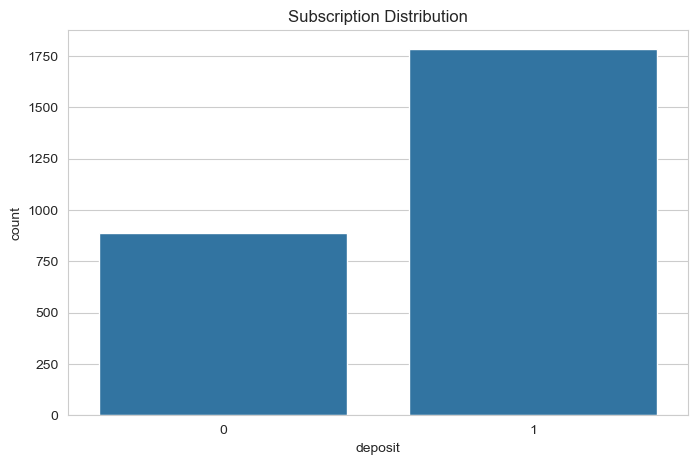

In [16]:
# Subscription Distribution
sns.countplot(x="deposit", data=df)
plt.title("Subscription Distribution")
plt.show()


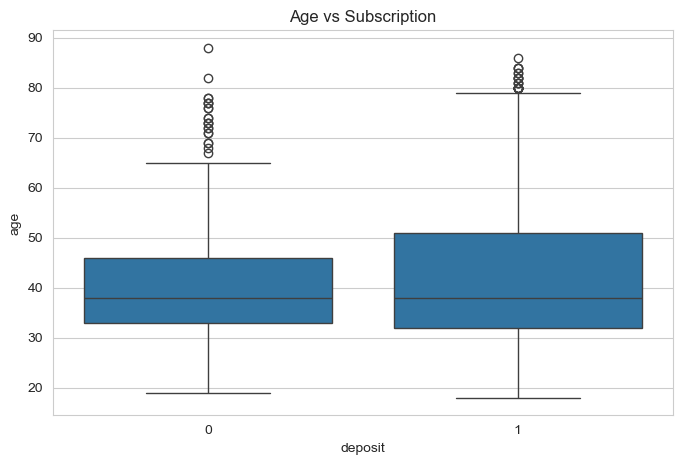

In [17]:
# Age vs Subscription
sns.boxplot(x="deposit", y="age", data=df)
plt.title("Age vs Subscription")
plt.show()



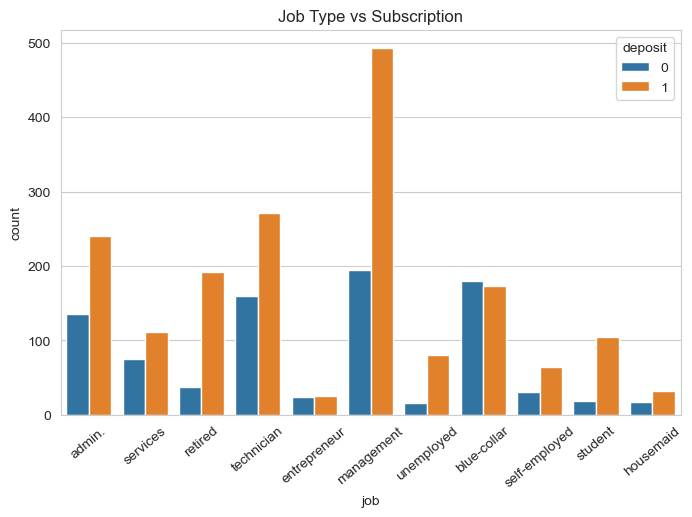

In [18]:
# Job vs Subscription
sns.countplot(x="job", hue="deposit", data=df)
plt.xticks(rotation=40)
plt.title("Job Type vs Subscription")
plt.show()


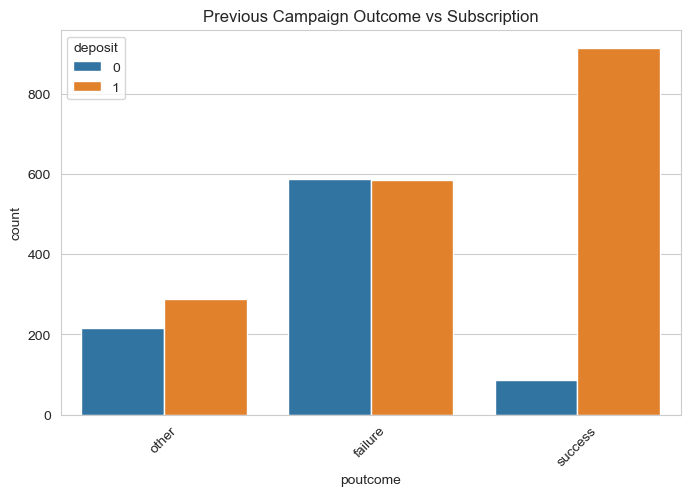

In [19]:
sns.countplot(x="poutcome", hue="deposit", data=df)
plt.xticks(rotation=45)
plt.title("Previous Campaign Outcome vs Subscription")
plt.show()


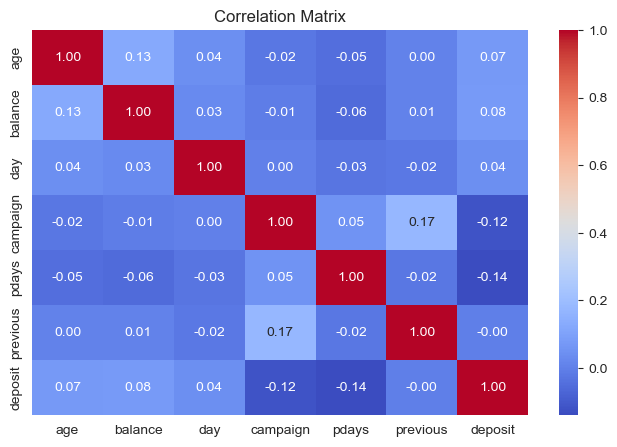

In [20]:
# Correlation matrix
numeric_df = df.select_dtypes(include=["int64","float64"])

sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


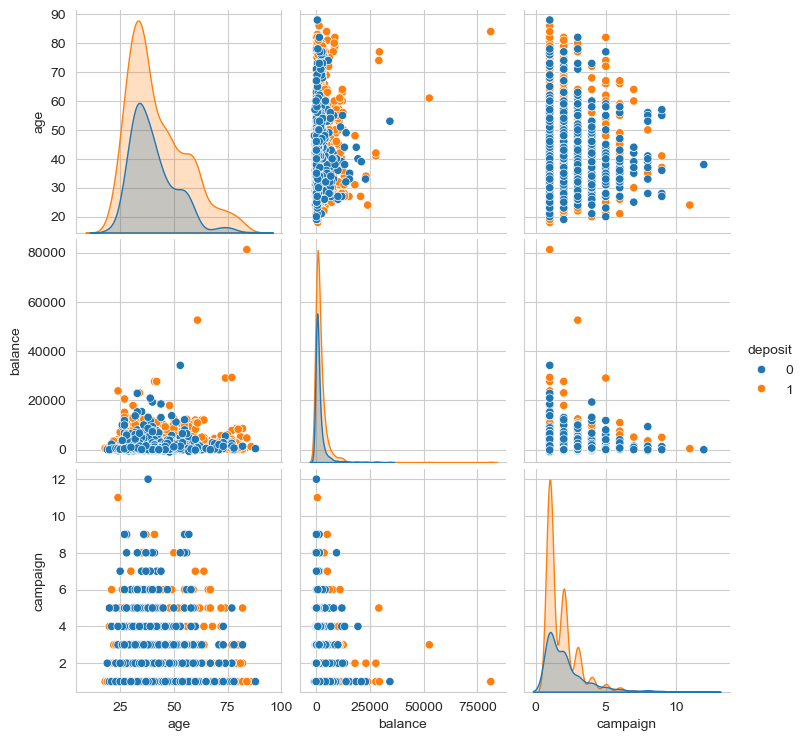

In [21]:
# Pairplot 
sns.pairplot(df[["age","balance","campaign","deposit"]], hue="deposit")
plt.show()


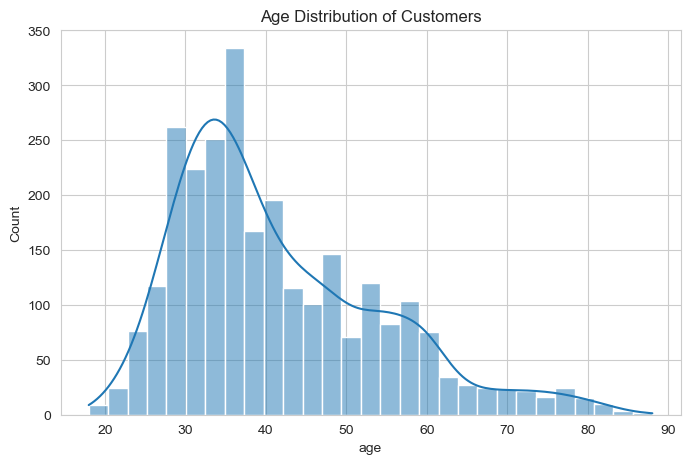

In [22]:
# Age Distribution
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution of Customers")
plt.show()


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2675 entries, 890 to 11160
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        2675 non-null   int64 
 1   job        2675 non-null   object
 2   marital    2675 non-null   object
 3   education  2675 non-null   object
 4   default    2675 non-null   object
 5   balance    2675 non-null   int64 
 6   housing    2675 non-null   object
 7   loan       2675 non-null   object
 8   contact    2675 non-null   object
 9   day        2675 non-null   int64 
 10  month      2675 non-null   object
 11  campaign   2675 non-null   int64 
 12  pdays      2675 non-null   int64 
 13  previous   2675 non-null   int64 
 14  poutcome   2675 non-null   object
 15  deposit    2675 non-null   int64 
dtypes: int64(7), object(9)
memory usage: 355.3+ KB
